# Lab 05 Cheatsheet
**Image Segmentation: Thresholding, Colour, Edges, Region Growing, Watershed & K-Means** | CV Practical Lab Exam

### Contents
| # | Section | # | Section |
|---|---|---|---|
| 0 | Setup | A | **Lab manual summary + manual code** |
| 1 | The segmentation toolbox (big picture) | 8 | Task 6 - Region growing (MRI) |
| 2 | General requirements checklist | 9 | Task 7 - Marker-based watershed (coins) |
| 3 | Task 1 - Global vs adaptive threshold (uneven lighting) | 10 | Task 8 - Tuning the distance-transform threshold |
| 4 | Task 2 - Adaptive parameters: blockSize, C, mean vs Gaussian | 11 | Task 9 - K-Means segmentation |
| 5 | Task 3 - Otsu's thresholding + histogram | 12 | Task 10 - Choose 3 methods for an unknown image |
| 6 | Task 4 - HSV colour segmentation | 13 | Function quick reference |
| 7 | Task 5 - Canny edges (hysteresis) | 14 | Common errors & exam checklist |

**One-line recipe for every task:** `load (gray / colour) -> pre-process (blur) -> segment -> compare parameters side by side -> record + justify parameters -> cv2.imwrite the final result`

---
## 0. Setup
Run this cell first. Every template below is a **plain script** (no helper functions apart from one in Task 6): copy a template, change the lines marked `# EDIT`, run.

**Images:** the Lab 5 handout does not ship its images, so `lab5/images/` holds **synthetic stand-ins** with the same properties. Replace the file names with the exam images.

| File in `images/` | Stands in for | Used in |
|---|---|---|
| `document.jpg` | phone photo of a page, bright on the left and dark on the right | Tasks 1, 2, 10 |
| `coins.jpg` | OpenCV watershed coins (17 coins, several touching, some small) | Tasks 3, 7, 8 |
| `colored_objects.jpg` | the yellow-car image (plus a red ball, blue box, green triangle, orange ellipse) | Task 4 |
| `part.jpg` | metal gear (strong, weak and unwanted edges) | Task 5 |
| `brain_mri.jpg` | brain MRI (white matter, grey matter, ventricles, a bright lesion) | Task 6 |
| `scene.jpg` | complex colour photo (a flower) | Task 9 |

**Display pattern used everywhere:**
```python
plt.figure(figsize = (12,5))
plt.subplot(1,2,1)
plt.imshow(img, cmap = 'gray')                     # gray / binary image
plt.title('Original')
plt.axis('off')
```
Colour (BGR) images need `cv2.cvtColor(img, cv2.COLOR_BGR2RGB)` before `plt.imshow`.

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 70
os.makedirs('output', exist_ok = True)        # every task saves its final result here

---
# A. Lab manual summary (AI-4002, Lab 05 - Image Segmentation)
Everything the manual covers, condensed. Sections 1-14 below turn it into task templates; this part is the **theory + the manual's own code**.

### A.1 Objectives and definition
**Objectives:** (1) intro to image segmentation, (2) techniques / methodologies, (3) **region-based** segmentation, (4) **edge-detection** segmentation, (5) **clustering-based** segmentation.

**Definition:** segmentation partitions an image into **distinct, non-overlapping regions**, each a meaningful object or part of the scene; pixels in a region share a visual characteristic (**colour, texture or intensity**).

**Pipeline in the manual's figure:** input image -> pre-processing and feature extraction (pixel values, edge detection, texture analysis, colour similarity) -> segmentation algorithm (region growing, clustering / K-Means, watershed, deep-learning CNN) -> segmented region map.

### A.2 Mathematics behind segmentation
| Family | Idea | Formula / detail from the manual |
|---|---|---|
| **Thresholding** | compare intensity with a predefined threshold | `S(x,y) = Object if I(x,y) > T, else Background` |
| **Edge detection** | rapid intensity change = object boundary | gradient `grad I = [dI/dx, dI/dy]^T`; methods: **Sobel** (gradient magnitude), **Canny** (multi-stage: noise reduction, gradient, non-maximum suppression, hysteresis thresholding), **Laplacian of Gaussian (LoG)** |
| **Clustering** | group similar pixels by feature similarity (colour values etc.) | **K-Means**: minimise `sum_j sum_i dist(x_i, mu_j)^2` (squared Euclidean distance) (sum of squared distances to the centroid): initialise K centroids -> assign points to the nearest centroid -> update centroids -> repeat until convergence. Also **Mean-Shift** |
| **Graph theory** | pixels = nodes, edge weight = similarity of the two pixels | partition with a **minimum spanning tree** or **graph cut** (min cut / max flow): `Cut cost = sum of w(e) for e in cut` |

### A.3 Real-life examples
| Field | Use |
|---|---|
| Medical imaging | isolate anatomical structures or **tumours** in X-ray, CT, MRI |
| Object detection (autonomous vehicles) | locate pedestrians, vehicles, road signs |
| Satellite imagery | classify land cover (urban, forest, water), monitor deforestation, urban growth |
| Biomedical imaging | microscopy: count cells, find nuclei, diagnose disease |
| Augmented reality | scene understanding, track objects in real-time video |

### A.4 Techniques in the manual
| Section | Technique | Methodology | Use case | Manual's code (default parameters) |
|---|---|---|---|---|
| 2.3.1.1 | **Global threshold** | one threshold for the whole image | clear intensity difference between object and background | `cv2.threshold(image, 128, 255, cv2.THRESH_BINARY)` |
| 2.3.1.2 | **Adaptive threshold** | different threshold per region, adapting to local intensity | varying lighting | `cv2.adaptiveThreshold(image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)` |
| 2.3.1.3 | **Otsu** | automatically picks the threshold that **maximises inter-class variance** | **bimodal** histogram | `cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)` |
| 2.3.1.4 | **Colour-based threshold** | threshold in several colour channels (RGB, HSV) | objects with distinct colours | `cv2.inRange(hsv, np.array([30,50,50]), np.array([60,255,255]))` |
| 2.3.1.5 | **Hysteresis (Canny)** | **high** threshold finds strong edges, **low** threshold links weak edges | edge detection, adaptable to segmentation | `cv2.Canny(image, 100, 200)` |
| 2.3.2 | **Edge detection** | boundaries = rapid change in intensity or colour | extract contours and boundaries | (Canny above) |
| 2.3.3 | **Region growing** | start at a **seed pixel**, expand to neighbours similar in intensity / colour | regions with uniform characteristics | stack-based function, `threshold = 50`, `seed_point = (10, 10)` |
| 2.3.4 | **Watershed** | image as a topographic map, simulate flooding | **touching or overlapping objects** | Otsu + 5x5 opening + dilate + `0.2 * dist.max()`, see A.5 |
| 2.3.5 | **Clustering (K-Means, Mean-Shift, DBSCAN)** | group pixels by feature similarity | complex characteristics | `cv2.kmeans(..., K = 4, criteria (100, 0.2), attempts = 10)` |
| 2.3.6 | **Deep learning (CNNs)** | semantic and instance segmentation | complex tasks, large datasets; frameworks TensorFlow, PyTorch, Keras | theory only |
| 2.3.7 | **Active contours (snakes)** | deformable models that evolve to object boundaries using gradients and constraints | object tracking, boundary refinement | theory only |

**Watershed steps (manual, conceptual):**
1. **Pre-processing:** to grayscale; noise reduction and contrast enhancement if needed.
2. **Marker generation:** manual placement, thresholding on intensity, or **distance transform** around object centres.
3. **Gradient calculation:** Sobel or Scharr filters highlight object boundaries.
4. **Marker labelling:** label each marker with a different integer.
5. **Watershed transformation:** gradient image = topographic surface (high gradient = peaks); fill basins from the markers; where basins meet = region boundaries.
6. **Post-processing (optional):** morphological erosion / dilation to refine.

**Clustering steps (manual):** (1) **feature extraction** (RGB, LAB or HSV for colour; intensity for gray); (2) **cluster initialisation** (choose K, initial centroids random or heuristic); (3) **K-Means loop**: assignment step (nearest centroid, Euclidean distance) + update step (centroid = mean of its pixels) until assignments stop changing; (4) **segmentation** (each cluster = one region); (5) optional **post-processing** (merge / split clusters).

**Exam tip:** the questions on DL, snakes, graph cuts, Mean-Shift, DBSCAN, Sobel and LoG are **definition-level**: use the "Methodology" and "Use case" wording above.

### A.5 The manual's code, run as given
Each cell below is the manual's snippet with only the **file names** changed to the sample images (and `cv2.imshow` replaced by `plt`, because `cv2.imshow` + `waitKey(0)` freezes a notebook). Parameters are the manual's defaults, so the results show what the *defaults* do on these images.

Otsu threshold chosen: 139.0


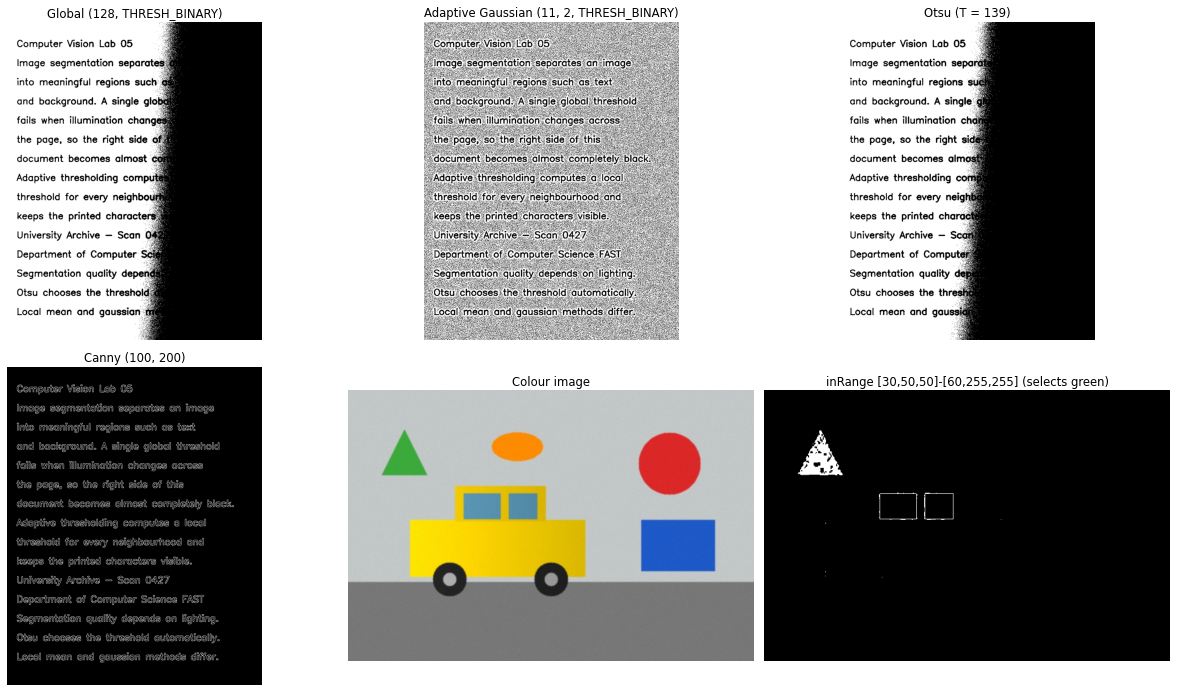

In [2]:
# ---------- MANUAL: 2.3.1 thresholding snippets (global, adaptive, Otsu, colour, Canny) ----------
image = cv2.imread('images/document.jpg', cv2.IMREAD_GRAYSCALE)                                   # manual: 'image.jpg'

_, global_mask = cv2.threshold(image, 128, 255, cv2.THRESH_BINARY)                                # 2.3.1.1 global
adaptive_mask = cv2.adaptiveThreshold(image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                      cv2.THRESH_BINARY, 11, 2)                                   # 2.3.1.2 adaptive
otsu_T, otsu_mask = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)             # 2.3.1.3 Otsu
edges = cv2.Canny(image, 100, 200)                                                                # 2.3.1.5 Canny

image_color = cv2.imread('images/colored_objects.jpg')
hsv_image = cv2.cvtColor(image_color, cv2.COLOR_BGR2HSV)                                          # 2.3.1.4 colour
lower_bound = np.array([30, 50, 50])
upper_bound = np.array([60, 255, 255])
color_mask = cv2.inRange(hsv_image, lower_bound, upper_bound)

print('Otsu threshold chosen:', otsu_T)

plt.figure(figsize = (18,10))
plt.subplot(2,3,1)
plt.imshow(global_mask, cmap = 'gray')
plt.title('Global (128, THRESH_BINARY)')
plt.axis('off')

plt.subplot(2,3,2)
plt.imshow(adaptive_mask, cmap = 'gray')
plt.title('Adaptive Gaussian (11, 2, THRESH_BINARY)')
plt.axis('off')

plt.subplot(2,3,3)
plt.imshow(otsu_mask, cmap = 'gray')
plt.title('Otsu (T = %d)' % otsu_T)
plt.axis('off')

plt.subplot(2,3,4)
plt.imshow(edges, cmap = 'gray')
plt.title('Canny (100, 200)')
plt.axis('off')

plt.subplot(2,3,5)
plt.imshow(cv2.cvtColor(image_color, cv2.COLOR_BGR2RGB))
plt.title('Colour image')
plt.axis('off')

plt.subplot(2,3,6)
plt.imshow(color_mask, cmap = 'gray')
plt.title('inRange [30,50,50]-[60,255,255] (selects green)')
plt.axis('off')

plt.tight_layout()
plt.show()

seed intensity: 147 | region size: 99051 pixels


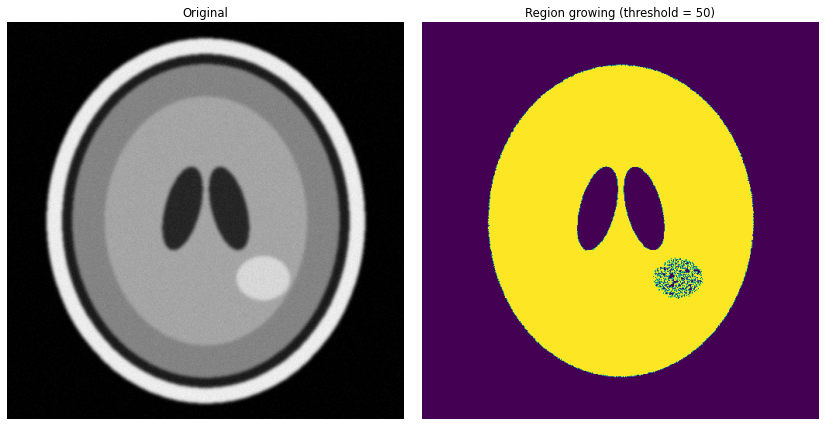

In [3]:
# ---------- MANUAL: 2.3.3 region growing (as given; seed is (row, col)) ----------
image = cv2.imread('images/brain_mri.jpg', cv2.IMREAD_GRAYSCALE)                                  # manual: 'ents.jpg'

seed_point = (256, 140)                                                                           # manual: (10, 10); here a white-matter pixel

def region_growing(image, seed, threshold):
    mask = np.zeros_like(image, dtype=np.uint8)           # empty mask for the segmented region
    stack = [seed]                                        # stack for pixel traversal
    seed_intensity = image[seed]                          # intensity at the seed
    while stack:
        x, y = stack.pop()
        if x < 0 or x >= image.shape[0] or y < 0 or y >= image.shape[1]:    # inside the image?
            continue
        if mask[x, y] == 0:                                                 # unvisited?
            if abs(int(image[x, y]) - int(seed_intensity)) < threshold:     # similar to the seed?
                mask[x, y] = 255
                stack.extend([(x + 1, y), (x - 1, y), (x, y + 1), (x, y - 1)])   # 4 neighbours
    return mask

threshold = 50                                                                                    # manual default
segmented_image = region_growing(image, seed_point, threshold)
print('seed intensity:', image[seed_point], '| region size:', np.count_nonzero(segmented_image), 'pixels')

plt.figure(figsize = (12,6))
plt.subplot(1,2,1)
plt.imshow(image, cmap = 'gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(segmented_image)
plt.title('Region growing (threshold = %d)' % threshold)
plt.axis('off')

plt.tight_layout()
plt.show()

regions found: 11 (coins in the image: 17)


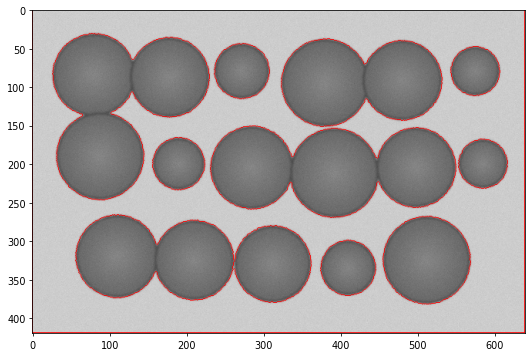

In [4]:
# ---------- MANUAL: 2.3.4 watershed (as given) ----------
image = cv2.imread('images/coins.jpg')                                                            # manual: 'dog.jpeg'
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

_, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)                  # markers from thresholding

kernel = np.ones((5, 5), np.uint8)                                                                # manual: 5x5 (Task 7 uses 3x3)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

sure_bg = cv2.dilate(opening, kernel, iterations=3)
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
_, sure_fg = cv2.threshold(dist_transform, 0.2 * dist_transform.max(), 255, 0)                    # manual: 0.2 * max

sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg, sure_fg)

_, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown == 255] = 0

cv2.watershed(image, markers)                          # modifies `markers` in place
image[markers == -1] = [255, 0, 0]                     # looks red ONLY because plt.imshow below treats the BGR array as RGB

print('regions found:', len([l for l in np.unique(markers) if l > 1]), '(coins in the image: 17)')

plt.figure(figsize = (10,6))
plt.imshow(image)                                      # manual shows the BGR array directly (no BGR2RGB)
plt.axis('on')
plt.show()

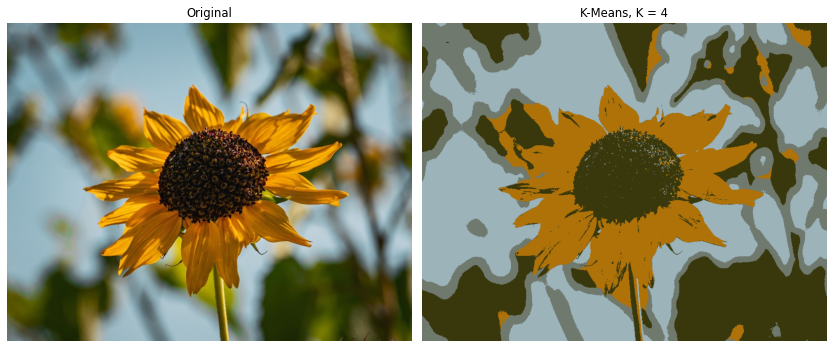

In [5]:
# ---------- MANUAL: 2.3.5 K-Means (as given) ----------
image = cv2.imread('images/scene.jpg')                                                            # manual: 'dogimg.jpg'

pixel_values = image.reshape((-1, 3))                                                             # 2D array of pixels
pixel_values = np.float32(pixel_values)                                                           # float32 for K-Means

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)                         # 100 iterations or eps 0.2
K = 4                                                                                             # number of clusters
_, labels, centers = cv2.kmeans(pixel_values, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

centers = np.uint8(centers)
segmented_image = centers[labels.flatten()]
segmented_image = segmented_image.reshape(image.shape)

# cv2.imshow('Segmented Image', segmented_image)       # manual: freezes a notebook, use plt instead
# cv2.waitKey(0)
# cv2.destroyAllWindows()

plt.figure(figsize = (12,5))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Original')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(segmented_image, cv2.COLOR_BGR2RGB))
plt.title('K-Means, K = %d' % K)
plt.axis('off')

plt.tight_layout()
plt.show()

**What the manual's defaults do on the sample images**

| Snippet | Observation |
|---|---|
| Global `128` / Otsu | the dark right side of the page turns solid black: text lost (the uneven-lighting failure) |
| Adaptive `11, 2` | text is readable but the whole page is covered in salt-and-pepper noise (`C = 2` is too small) |
| Colour `[30,50,50]-[60,255,255]` | selects the **green** triangle, not the yellow car (yellow needs H about 20-35) |
| Region growing `threshold = 50` | from a white-matter seed it floods about 99,000 pixels, i.e. the whole brain: the threshold is too large for this image (Task 6 uses 10-40) |
| Watershed `0.2 * max`, 5x5 kernel | only about 11 regions for 17 coins: touching coins stay merged (Task 8 finds about 0.5 works) |
| K-Means `K = 4` | four flat colour regions (poster look) |

### A.6 Manual defaults vs the task templates
The lab **tasks** override several of the manual's defaults. If a question says "use the manual's code", use the left column; for the tasks use the template.

| Item | Manual's code | Task templates (sections 3-12) | Why it differs |
|---|---|---|---|
| Global threshold | `128`, `THRESH_BINARY` | three values, `THRESH_BINARY_INV` | the task wants a comparison; INV makes dark text white |
| Adaptive | Gaussian, `THRESH_BINARY`, `blockSize 11`, `C 2` | Gaussian, `THRESH_BINARY_INV`, `31`, `10` | 11 / 2 leaves a lot of paper noise (see the figure above and Task 2) |
| Colour range | `[30,50,50]` to `[60,255,255]` (**green**) | `[20,100,100]` to `[35,255,255]` (**yellow**) | pick the hue of your object; yellow is H about 20-35 |
| Canny | `(100, 200)` | three pairs | the task studies the thresholds |
| Region growing seed | `(10, 10)` as **(row, col)**: `image[seed]`, `mask[x, y]` | `(x, y)` = (column, row): `image[y, x]` | the manual's `x` runs along the **height** (`x >= image.shape[0]`); use one convention consistently |
| Neighbours / test | **4** neighbours, `diff < threshold` | **8** neighbours, `diff <= threshold` | 8-connectivity grows through diagonal gaps |
| Region growing stack | pushes neighbours **before** checking visited (a pixel can be pushed many times) | marks the pixel when pushed | same result, far fewer stack entries |
| Watershed kernel | `5x5`, factor `0.2` | `3x3`, factor `0.5` | `0.2` merges touching coins; Task 8 sweeps this factor |
| Watershed boundary colour | `[255,0,0]` (**blue** in BGR, but shown red because `plt.imshow` reads it as RGB) | `[0,0,255]` (red in BGR) | with a proper BGR2RGB conversion `[0,0,255]` is the red one |
| Watershed display | `plt.imshow(image)` without conversion | `cv2.cvtColor(..., COLOR_BGR2RGB)` | otherwise the picture's colours are swapped |
| K-Means criteria | `(EPS + MAX_ITER, 100, 0.2)`, attempts `10`, `K = 4` | same, `K = 2, 4, 6` | the task asks for three K values |
| K-Means display | `cv2.imshow` + `waitKey(0)` | `plt.imshow` | `waitKey(0)` freezes a notebook |

---
# 1. The segmentation toolbox (big picture)

Segmentation = splitting an image into regions (usually object vs background). Pick the method from **what makes the object different from the background**.

| Method | Idea | Key call | Parameter(s) | Works when | Fails when |
|---|---|---|---|---|---|
| **Global threshold** | one fixed intensity cut for every pixel | `cv2.threshold(g, T, 255, type)` | `T` | even lighting, 2 clear intensity classes | lighting changes across the image |
| **Adaptive threshold** | cut = (local mean or Gaussian-weighted mean) minus `C` | `cv2.adaptiveThreshold(g, 255, method, type, blockSize, C)` | `blockSize` (odd), `C`, mean/Gaussian | uneven illumination, text, thin structures | big flat objects (their middle looks like background) |
| **Otsu** | picks `T` automatically from the histogram (minimises within-class variance) | `cv2.threshold(g, 0, 255, type + cv2.THRESH_OTSU)` | none (returns `T`) | **bimodal** histogram | unimodal histogram, uneven lighting |
| **Colour (HSV)** | keep pixels inside a hue / saturation / value box | `cv2.inRange(hsv, lower, upper)` | lower and upper bounds | object has a distinct colour | similar hue in the background |
| **Canny** | gradient edges + non-max suppression + 2-threshold hysteresis | `cv2.Canny(g, low, high)` | `low`, `high` | you want boundaries, not regions | noisy images (unwanted edges) |
| **Region growing** | start at a seed, add 8-neighbours whose intensity is close | (hand-written loop) | seed, intensity threshold | one connected region of similar intensity | region touches similar tissue (leaks) |
| **Watershed** | flood from markers; ridges between markers become boundaries | `cv2.watershed(img, markers)` | distance-transform threshold | touching convex objects | bad markers (merges / over-splits) |
| **K-Means** | cluster pixels by colour, repaint each pixel with its cluster centre | `cv2.kmeans(data, K, None, criteria, attempts, flags)` | `K` | many colours, want simplification | needs the number of clusters; ignores position |

**Threshold type constants** (the 4th argument of `cv2.threshold` / 4th of `adaptiveThreshold`)

| Constant | Result |
|---|---|
| `cv2.THRESH_BINARY` | pixel > T -> 255 (white), else 0 |
| `cv2.THRESH_BINARY_INV` | pixel > T -> 0, else 255 (**dark objects on light background become white**) |
| `cv2.THRESH_OTSU` | add to the type (`+`) and pass `T = 0`; OpenCV returns the chosen `T` |

**Rule of thumb:** make the **object white (255)** in every mask. Dark text on paper, dark coins on a light tray: use `THRESH_BINARY_INV`.

---
# 2. General requirements checklist

The handout asks for the **same five things in every task**:

| Requirement | How |
|---|---|
| Use Python, OpenCV, NumPy | `import cv2, numpy as np` |
| Display the **original and the segmentation result** | `plt.subplot` side by side with titles |
| **No** prebuilt segmentation library / deep-learning model | only `cv2` / `numpy` calls from this sheet |
| **Record the parameters and justify them** | print them, and write one line of reason (table below) |
| **Save the final output** | `cv2.imwrite('output/task1_result.png', result)` |

**Parameter log template** (copy under each task in your answer notebook)

| Parameter | Value | Why |
|---|---|---|
| e.g. `blockSize` | 31 | bigger than a stroke width (about 3 px) but small enough to follow the lighting gradient |
| e.g. `C` | 10 | suppresses paper noise without thinning the characters |
| e.g. `low / high` | 50 / 150 | ratio about 1:3, keeps weak edges only when they touch a strong one |

**Saving:** `cv2.imwrite(path, img)` writes a **BGR** (or gray) `uint8` array. Masks are already 0/255 so they save as-is. If a float array slips in, convert first: `np.uint8(img)`.

---
# 3. Task 1 - Global vs adaptive threshold (uneven lighting)
**Scenario:** a phone photo of a page is bright on one side and dark on the other. Separate the printed text from the paper.

| Step | What | Call |
|---|---|---|
| 1 | Load in grayscale | `cv2.imread(path, cv2.IMREAD_GRAYSCALE)` |
| 2 | Global threshold, **3 different values** | `cv2.threshold(g, T, 255, cv2.THRESH_BINARY_INV)` for `T` = 60, 127, 170 |
| 3 | Compare the three masks | look at both halves of the page |
| 4 | Adaptive threshold | `cv2.adaptiveThreshold(g, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 31, 10)` |
| 5 | Compare adaptive vs the **best global** | best global = the one that keeps the most text on both sides |
| 6 | Say which regions make global fail | the dark side (and the very bright side for low `T`) |
| 7 | Choose the most usable mask | adaptive Gaussian |

**Required output:** `Original -> Global T1 -> Global T2 -> Global T3 -> Adaptive` in one figure, with the answer to *"Why does a single threshold struggle when illumination changes?"* under the last panel.

**Model answer:** a global threshold assumes paper and ink have the **same brightness everywhere**. With a lighting gradient the paper on the dark side is darker than the ink on the bright side, so the two intensity ranges **overlap** and no single `T` separates them. A high `T` turns the dark-side paper black (noise everywhere); a low `T` loses the ink on the bright side. Adaptive thresholding computes `T` from each pixel's own neighbourhood, so it only compares ink with the paper right next to it.

**Pitfalls**
- `blockSize` must be **odd and > 1** (`cv2.error` otherwise).
- Use `THRESH_BINARY_INV` for dark text, otherwise the text comes out black on a white mask.
- `cv2.threshold` **returns two values**: `ret, mask = cv2.threshold(...)`. `adaptiveThreshold` returns only the mask.

global T1  ink on left half:   0.1 %   right half:   3.8 %
global T2  ink on left half:  10.6 %   right half:  81.1 %
global T3  ink on left half:  41.5 %   right half: 100.0 %
adaptive   ink on left half:  11.1 %   right half:   6.2 %


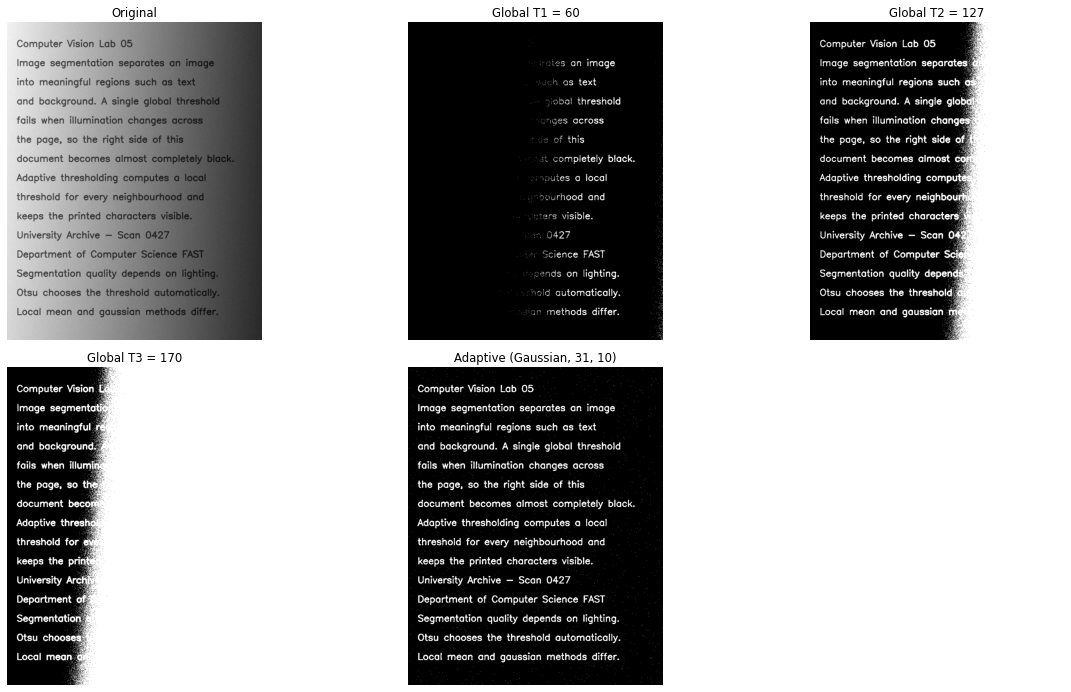

In [6]:
# ---------- TEMPLATE: global thresholds vs adaptive threshold ----------
gray = cv2.imread('images/document.jpg', cv2.IMREAD_GRAYSCALE)        # EDIT: document image

T1, T2, T3 = 60, 127, 170                                             # EDIT: three global thresholds
ret, g1 = cv2.threshold(gray, T1, 255, cv2.THRESH_BINARY_INV)
ret, g2 = cv2.threshold(gray, T2, 255, cv2.THRESH_BINARY_INV)
ret, g3 = cv2.threshold(gray, T3, 255, cv2.THRESH_BINARY_INV)

adaptive = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                 cv2.THRESH_BINARY_INV, 31, 10)       # EDIT: blockSize, C

# evidence: % of white (ink) pixels on the bright (left) and dark (right) half
# a good text mask has a similar % on both halves
w = gray.shape[1] // 2
for name, m in (('global T1', g1), ('global T2', g2), ('global T3', g3), ('adaptive', adaptive)):
    print('%-10s ink on left half: %5.1f %%   right half: %5.1f %%' % (name, m[:, :w].mean() / 2.55, m[:, w:].mean() / 2.55))

cv2.imwrite('output/task1_adaptive.png', adaptive)                    # save the final output

plt.figure(figsize = (18,10))
plt.subplot(2,3,1)
plt.imshow(gray, cmap = 'gray')
plt.title('Original')
plt.axis('off')

plt.subplot(2,3,2)
plt.imshow(g1, cmap = 'gray')
plt.title('Global T1 = %d' % T1)
plt.axis('off')

plt.subplot(2,3,3)
plt.imshow(g2, cmap = 'gray')
plt.title('Global T2 = %d' % T2)
plt.axis('off')

plt.subplot(2,3,4)
plt.imshow(g3, cmap = 'gray')
plt.title('Global T3 = %d' % T3)
plt.axis('off')

plt.subplot(2,3,5)
plt.imshow(adaptive, cmap = 'gray')
plt.title('Adaptive (Gaussian, 31, 10)')
plt.axis('off')

plt.tight_layout()
plt.show()

---
# 4. Task 2 - Adaptive parameters: blockSize, C, mean vs Gaussian
**Scenario:** just switching to adaptive is not enough: some settings break characters, others add black noise. Find how `blockSize` and `C` behave.

`cv2.adaptiveThreshold(src, maxValue, adaptiveMethod, thresholdType, blockSize, C)`

| Argument | Meaning |
|---|---|
| `adaptiveMethod` | `cv2.ADAPTIVE_THRESH_MEAN_C`: local **mean**. `cv2.ADAPTIVE_THRESH_GAUSSIAN_C`: **Gaussian-weighted** mean (centre pixels count more) |
| `blockSize` | side of the neighbourhood in pixels, **odd** (11, 31, 101 ...) |
| `C` | constant **subtracted** from the local mean: `T(x,y) = local_mean(x,y) - C` |

With `THRESH_BINARY_INV` a pixel becomes foreground when `pixel < T(x,y)`.

**Experiment grid (required):** `blockSize` = 11, 31, 101 (**3 values**) x mean / Gaussian (**2 methods**) = **6 results** + original; then `C` = 2, 10, 20 (**3 values**) at a fixed `blockSize`.

**Model answers**

| Question | Answer |
|---|---|
| Neighbourhood **too small** | smaller than a stroke: the middle of a thick stroke looks like "background" compared with itself, so characters become hollow / broken, and paper noise gets picked up |
| Neighbourhood **too large** | the local mean approaches the global mean: the lighting gradient comes back (dark patches / lost text on one side), and it is slower |
| `C` **increased** | threshold `mean - C` is lower, so fewer pixels qualify: less black noise, but thin strokes break up. `C` too low (0-2) fills the page with noise |
| Cleanest combination | about `blockSize` 31-51 (roughly 10x the stroke width) and `C` about 10 |
| Better method | **Gaussian** is usually a little cleaner: it gives less weight to far pixels so the threshold follows the edge of the stroke more smoothly. Mean is a box filter and shows square artefacts |

**Pitfalls**
- Compare methods at the **same** `blockSize` and `C`, otherwise you cannot tell what caused the change.
- Change **one** parameter at a time.

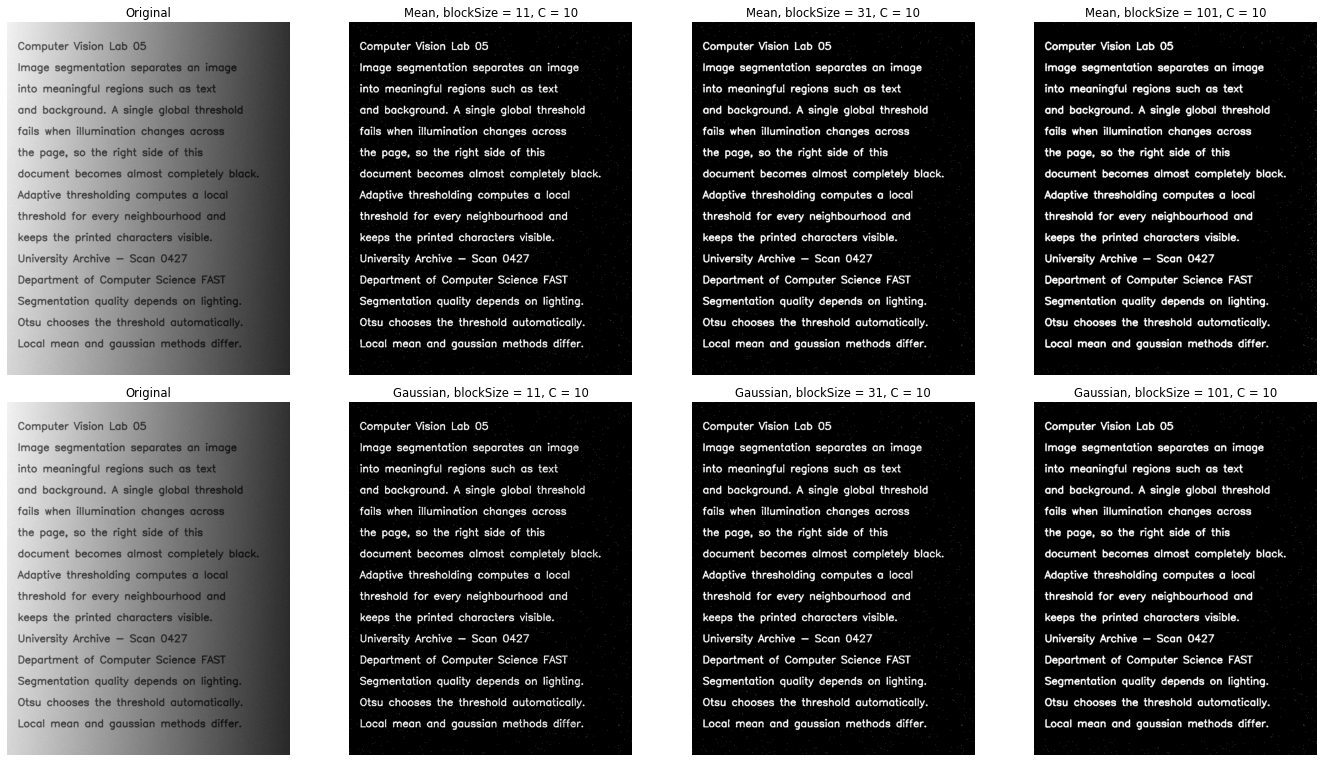

C =  2 -> 28.6 % of the page is foreground
C = 10 -> 8.7 % of the page is foreground
C = 20 -> 8.0 % of the page is foreground


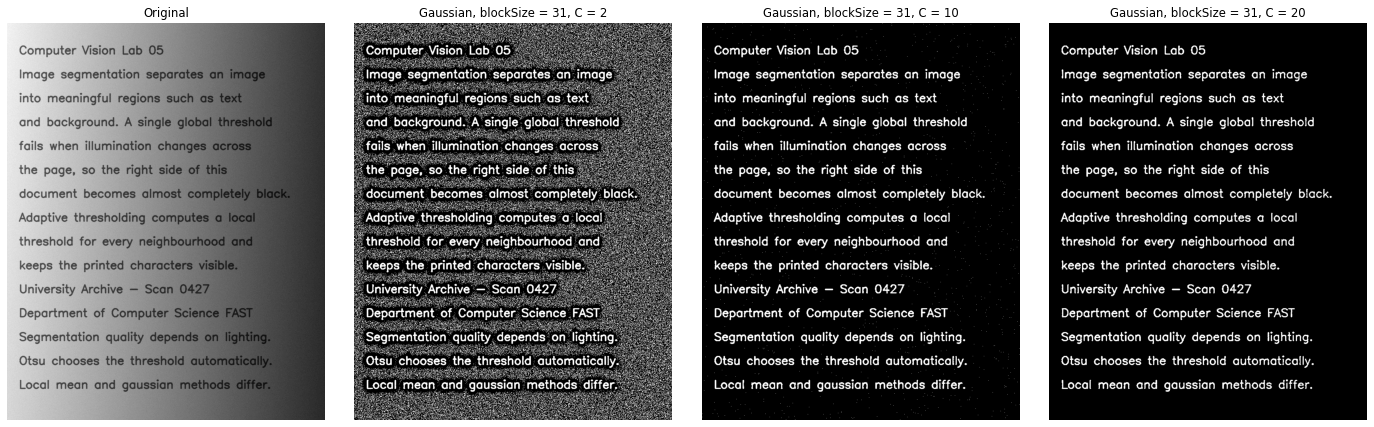

True

In [7]:
# ---------- TEMPLATE: parameter comparison (6 adaptive results + C sweep) ----------
gray = cv2.imread('images/document.jpg', cv2.IMREAD_GRAYSCALE)        # same image as Task 1

block_sizes = [11, 31, 101]                                           # EDIT: three blockSize values (odd)
C_fixed = 10

plt.figure(figsize = (20,11))
plt.subplot(2,4,1)
plt.imshow(gray, cmap = 'gray')
plt.title('Original')
plt.axis('off')
plt.subplot(2,4,5)
plt.imshow(gray, cmap = 'gray')
plt.title('Original')
plt.axis('off')

for i, bs in enumerate(block_sizes):
    mean_mask = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY_INV, bs, C_fixed)
    gauss_mask = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, bs, C_fixed)

    plt.subplot(2,4,2 + i)
    plt.imshow(mean_mask, cmap = 'gray')
    plt.title('Mean, blockSize = %d, C = %d' % (bs, C_fixed))
    plt.axis('off')

    plt.subplot(2,4,6 + i)
    plt.imshow(gauss_mask, cmap = 'gray')
    plt.title('Gaussian, blockSize = %d, C = %d' % (bs, C_fixed))
    plt.axis('off')

plt.tight_layout()
plt.show()

# C sweep at a fixed blockSize
C_values = [2, 10, 20]                                                # EDIT: three C values
plt.figure(figsize = (20,6))
plt.subplot(1,4,1)
plt.imshow(gray, cmap = 'gray')
plt.title('Original')
plt.axis('off')

for i, C in enumerate(C_values):
    m = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 31, C)
    print('C = %2d -> %.1f %% of the page is foreground' % (C, m.mean() / 2.55))
    plt.subplot(1,4,2 + i)
    plt.imshow(m, cmap = 'gray')
    plt.title('Gaussian, blockSize = 31, C = %d' % C)
    plt.axis('off')

plt.tight_layout()
plt.show()

best = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 31, 10)
cv2.imwrite('output/task2_best_adaptive.png', best)

---
# 5. Task 3 - Otsu's thresholding + histogram
**Scenario:** objects photographed on a fairly constant background; the engineer does not want to pick `T` by hand for every image.

| Step | What | Call |
|---|---|---|
| 1 | Grayscale | `cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)` (or load with `IMREAD_GRAYSCALE`) |
| 2 | Histogram | `plt.hist(gray.ravel(), 256, [0, 256])` |
| 3 | Otsu | `ret, mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)` |
| 4 | Record the chosen threshold | `ret` (first return value) |
| 5 | Repeat after a small contrast / pre-processing change | `cv2.convertScaleAbs(gray, alpha=..., beta=...)` or `cv2.GaussianBlur` |
| 6 | Compare the automatic thresholds | print them side by side |

**Required output:** `Original -> Histogram -> Otsu Binary Mask`.

**Model answer (why Otsu?):** Otsu tries every `T` from 0 to 255 and keeps the one that **minimises the variance inside the two classes** (equivalently maximises the variance between them). For a bimodal histogram that is the valley between the two peaks. The programmer never needs to know the right threshold: when lighting or contrast changes, the histogram moves and **Otsu's threshold moves with it**, whereas a hard-coded 127 would be wrong.

**Pitfalls**
- With `THRESH_OTSU` the `T` you pass (0) is **ignored**; do not pass your own number.
- Needs an **8-bit single-channel** image.
- A **blur first** (`cv2.GaussianBlur(gray, (5,5), 0)`) makes the histogram cleaner and the valley easier to find.
- If the histogram is not bimodal (or lighting is uneven), Otsu fails: use adaptive.

Otsu threshold (original)        : 158.0
Otsu threshold (lower contrast)  : 134.0
Otsu threshold (after blur)      : 158.0


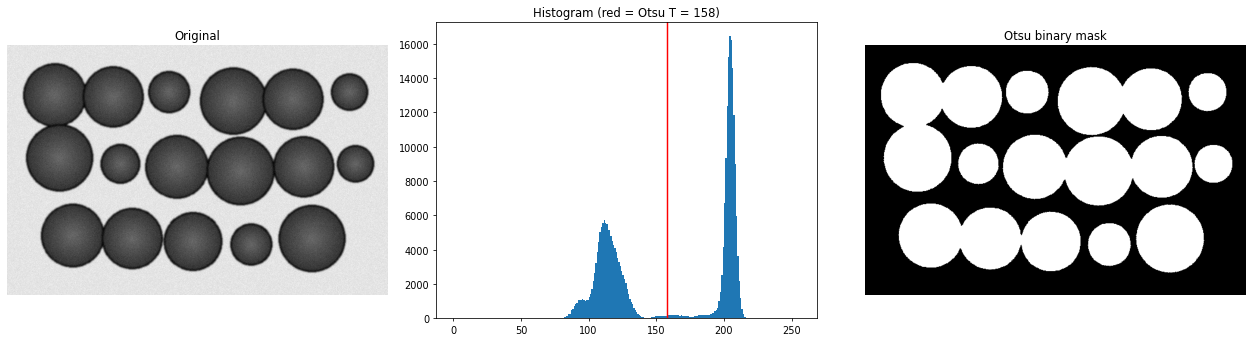

In [8]:
# ---------- TEMPLATE: Otsu + histogram + effect of contrast change ----------
img = cv2.imread('images/coins.jpg')                                  # EDIT: object image
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

ret, otsu_mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
print('Otsu threshold (original)        :', ret)

# change the contrast / pre-processing slightly and repeat
low_contrast = cv2.convertScaleAbs(gray, alpha = 0.6, beta = 40)      # EDIT: gain and offset
ret2, mask2 = cv2.threshold(low_contrast, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
print('Otsu threshold (lower contrast)  :', ret2)

blurred = cv2.GaussianBlur(gray, (5, 5), 0)
ret3, mask3 = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
print('Otsu threshold (after blur)      :', ret3)

cv2.imwrite('output/task3_otsu_mask.png', otsu_mask)

plt.figure(figsize = (18,5))
plt.subplot(1,3,1)
plt.imshow(gray, cmap = 'gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1,3,2)
plt.hist(gray.ravel(), 256, [0, 256])
plt.axvline(ret, color = 'r')
plt.title('Histogram (red = Otsu T = %d)' % ret)

plt.subplot(1,3,3)
plt.imshow(otsu_mask, cmap = 'gray')
plt.title('Otsu binary mask')
plt.axis('off')

plt.tight_layout()
plt.show()

---
# 6. Task 4 - HSV colour segmentation
**Scenario:** a sorting robot needs a binary mask of one coloured object (the yellow car). Brightness alone cannot separate it from the background.

| Step | What | Call |
|---|---|---|
| 1 | Load in colour | `cv2.imread(path)` (BGR) |
| 2 | Convert to HSV | `cv2.cvtColor(img, cv2.COLOR_BGR2HSV)` |
| 3 | Lower and upper range | `lower = np.array([H, S, V])`, `upper = np.array([H, S, V])` |
| 4 | Mask | `mask = cv2.inRange(hsv, lower, upper)` |
| 5 | Experiment with the limits | widen / narrow each channel |
| 6 | Extract the colour from the original | `cv2.bitwise_and(img, img, mask = mask)` |

**OpenCV HSV ranges (8-bit):** `H` **0-179** (half of the 0-360 degrees), `S` 0-255, `V` 0-255.

| Colour | H range (approx.) |
|---|---|
| red | 0-10 **and** 170-179 (wraps around: two masks) |
| orange | 10-20 |
| yellow | 20-35 |
| green | 35-85 |
| blue | 90-130 |

**Challenge: two masks.** Too-restrictive: `[28,240,240]` to `[32,255,255]`. Final: `[20,100,100]` to `[35,255,255]`.

**Model answer (why the restrictive mask fails):** H encodes the colour but **S and V change with lighting, shading and highlights**. A car body is not one exact (H,S,V) value: one side is darker, a highlight is whiter. A narrow box keeps only the few pixels that match exactly (a handful of pixels here), so the object is mostly missed. The fix is a **tight H range** (the colour identity) with **wide S and V ranges** (the lighting).

**Pitfalls**
- `inRange` takes **three-element NumPy arrays** for the bounds, not tuples of the wrong length.
- Convert BGR -> HSV (`COLOR_BGR2HSV`), not RGB -> HSV, because `cv2.imread` gives BGR.
- Too wide an H range pulls in neighbouring colours (orange objects with yellow).
- To show the extracted colour with `plt.imshow` convert the result BGR -> RGB.

restrictive mask pixels: 5
final mask pixels      : 33728


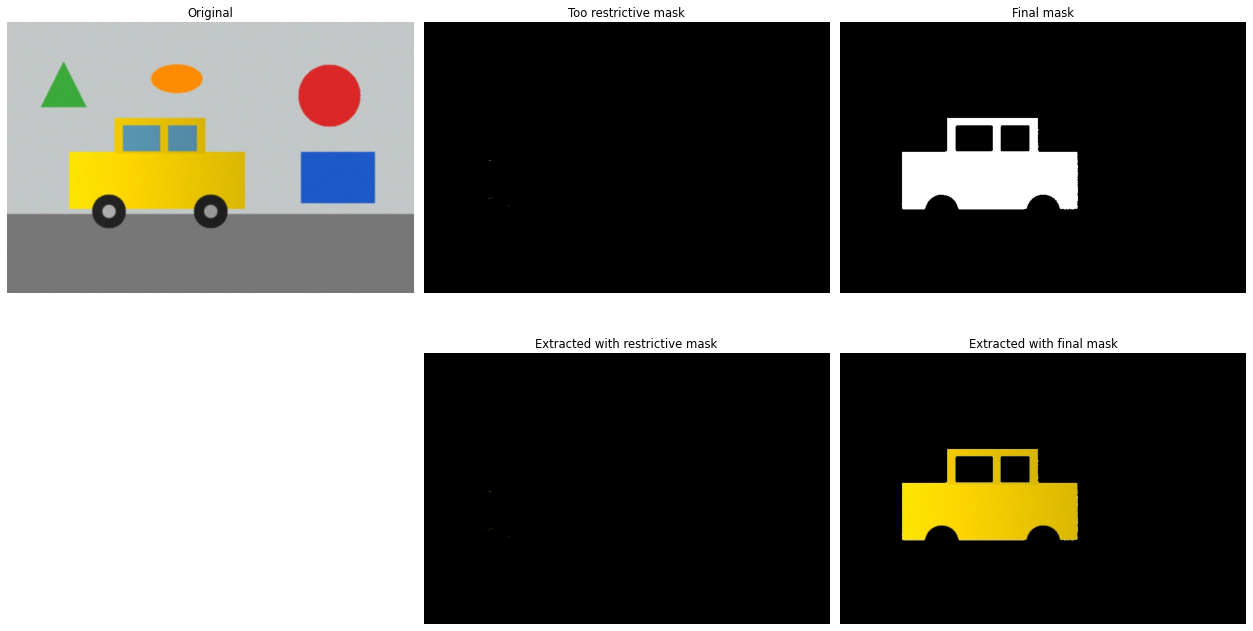

In [9]:
# ---------- TEMPLATE: HSV colour segmentation with a restrictive and a final mask ----------
img = cv2.imread('images/colored_objects.jpg')                        # EDIT: colour image
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# too-restrictive range: only the exact pixels that happen to match
lower_bad = np.array([28, 240, 240])                                  # EDIT
upper_bad = np.array([32, 255, 255])
mask_bad = cv2.inRange(hsv, lower_bad, upper_bad)

# final range: tight hue, wide saturation and value
lower = np.array([20, 100, 100])                                      # EDIT
upper = np.array([35, 255, 255])
mask = cv2.inRange(hsv, lower, upper)

extracted_bad = cv2.bitwise_and(img, img, mask = mask_bad)
extracted = cv2.bitwise_and(img, img, mask = mask)

print('restrictive mask pixels:', np.count_nonzero(mask_bad))
print('final mask pixels      :', np.count_nonzero(mask))

cv2.imwrite('output/task4_mask.png', mask)
cv2.imwrite('output/task4_extracted.png', extracted)

plt.figure(figsize = (18,10))
plt.subplot(2,3,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Original')
plt.axis('off')

plt.subplot(2,3,2)
plt.imshow(mask_bad, cmap = 'gray')
plt.title('Too restrictive mask')
plt.axis('off')

plt.subplot(2,3,3)
plt.imshow(mask, cmap = 'gray')
plt.title('Final mask')
plt.axis('off')

plt.subplot(2,3,5)
plt.imshow(cv2.cvtColor(extracted_bad, cv2.COLOR_BGR2RGB))
plt.title('Extracted with restrictive mask')
plt.axis('off')

plt.subplot(2,3,6)
plt.imshow(cv2.cvtColor(extracted, cv2.COLOR_BGR2RGB))
plt.title('Extracted with final mask')
plt.axis('off')

plt.tight_layout()
plt.show()

---
# 7. Task 5 - Canny edges (hysteresis)
**Scenario:** find the boundary of a mechanical part; the interior does not matter. The image has strong and weak edges.

`edges = cv2.Canny(image, threshold1 (low), threshold2 (high))`

**The Canny pipeline:** Gaussian smoothing -> gradient magnitude and direction (Sobel) -> **non-maximum suppression** (thin to 1 px) -> **hysteresis thresholding**.

**Hysteresis (the two thresholds):**

| Gradient strength | Classified as | Kept? |
|---|---|---|
| above `high` | **strong edge** | always |
| between `low` and `high` | **weak edge** | **only if connected to a strong edge** |
| below `low` | not an edge | never |

**Required:** three `(low, high)` pairs, e.g. `(50,100)`, `(50,200)`, `(150,250)`. To study the high threshold, **keep `low` fixed and raise `high`**.

**Model answers**

| Item | What it is |
|---|---|
| Strong edges | the gear outline and the centre hole: large intensity jump, survive every setting |
| Weak edges | the raised ring and the bolt holes: small jump, appear only when `high` is low enough (or are connected to a strong edge) |
| Missing edges | weak edges that disappear when `high` is raised: weak chains lose their strong anchor |
| Unwanted edges | scratches and noise specks that show up when `low` is small |
| Effect of the thresholds | raising **high** -> fewer strong seeds -> fewer edges overall; lowering **low** -> weak edges extend further and noise joins in; `high` about 2-3x `low` is the usual ratio |

**Pitfalls**
- Canny takes an **8-bit grayscale** image; blur first (`cv2.GaussianBlur(gray, (5,5), 0)`) to reduce noise edges.
- Result is 0/255 thin lines; count edge pixels with `np.count_nonzero(edges)` as numeric evidence.
- `low >= high` makes hysteresis meaningless.

low =  50, high = 100 ->  3274 edge pixels
low =  50, high = 200 ->   899 edge pixels
low = 150, high = 250 ->   514 edge pixels


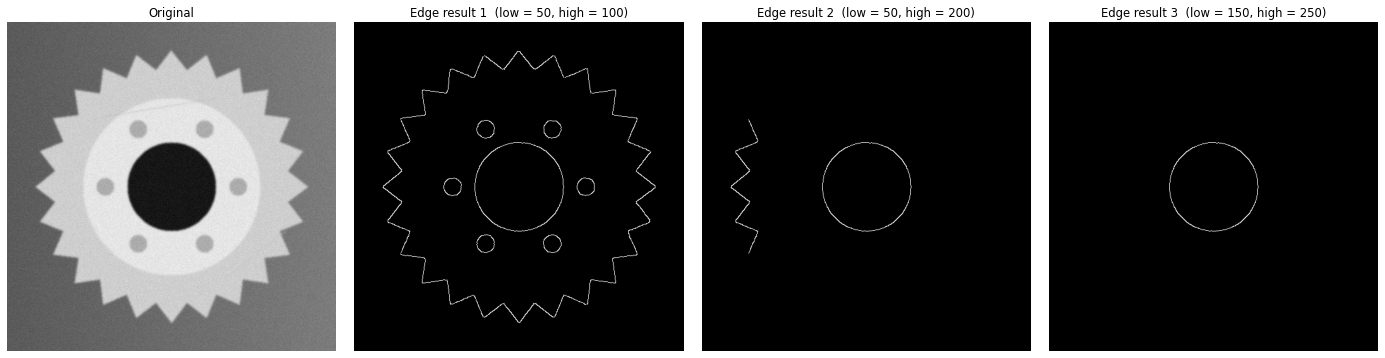

In [10]:
# ---------- TEMPLATE: Canny with three threshold pairs ----------
gray = cv2.imread('images/part.jpg', cv2.IMREAD_GRAYSCALE)            # EDIT: object image
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

pairs = [(50, 100), (50, 200), (150, 250)]                            # EDIT: (low, high) x 3

plt.figure(figsize = (20,5))
plt.subplot(1,4,1)
plt.imshow(gray, cmap = 'gray')
plt.title('Original')
plt.axis('off')

for i, (low, high) in enumerate(pairs):
    edges = cv2.Canny(blurred, low, high)
    print('low = %3d, high = %3d -> %5d edge pixels' % (low, high, np.count_nonzero(edges)))
    cv2.imwrite('output/task5_canny_%d_%d.png' % (low, high), edges)

    plt.subplot(1,4,2 + i)
    plt.imshow(edges, cmap = 'gray')
    plt.title('Edge result %d  (low = %d, high = %d)' % (i + 1, low, high))
    plt.axis('off')

plt.tight_layout()
plt.show()

---
# 8. Task 6 - Region growing (MRI)
**Scenario:** isolate a contiguous region of similar intensity in a brain MRI by starting from a **seed** and absorbing similar neighbours.

| Step | What |
|---|---|
| 1 | Load grayscale (blur lightly to tame noise) |
| 2 | Pick a seed point `(x, y)` = `(column, row)` |
| 3 | Put the seed on a stack and mark it |
| 4 | Pop a pixel, look at its 8 neighbours; if `abs(neighbour - seed_value) <= threshold` and not yet marked, mark it and push it |
| 5 | Repeat until the stack is empty: the marked pixels are the **binary mask** |

**Parameter study (required):** **3 thresholds** (e.g. 10, 25, 40) and **2 seeds** (e.g. one in white matter, one in grey matter or the lesion).

**Model answer (why does the seed matter?):** region growing is **local and compares every pixel with the seed's intensity**. A different seed has a different reference intensity (grey matter 120, white matter 150, lesion 190), so a different set of pixels passes the test, and growth can only proceed through **connected** pixels, so a seed enclosed by a boundary can never reach a similar region on the other side. A seed on a noisy or boundary pixel can also give an unrepresentative reference value.

**Threshold effect:** too small -> region stays tiny / fragmented (noise stops it); too large -> **leaks** into neighbouring tissue (in the sample, the white-matter seed floods into the grey matter at 40 and would reach the lesion at about 45; the grey-matter seed jumps from a thin ring at 10-25 to the whole brain at 40).

**Pitfalls**
- Images are `uint8`: `int(a) - int(b)` (or `np.int16`) **before** subtracting, otherwise `120 - 150` wraps to 226.
- Index with `image[y, x]` (row, column) but store the seed as `(x, y)`. (The manual's version indexes `image[x, y]` with `x` = row; see A.6.)
- Use a **stack and a mask**, never recursion (Python's recursion limit is about 1000).
- Check bounds (`0 <= nx < w`) before reading a neighbour.
- This is the one template with a **helper function** (it is called 6 times).

seed (140, 256), threshold 10 ->  52254 pixels


seed (140, 256), threshold 25 ->  56366 pixels


seed (140, 256), threshold 40 ->  95626 pixels


seed (100, 256), threshold 10 ->  39825 pixels


seed (100, 256), threshold 25 ->  44486 pixels


seed (100, 256), threshold 40 ->  98227 pixels


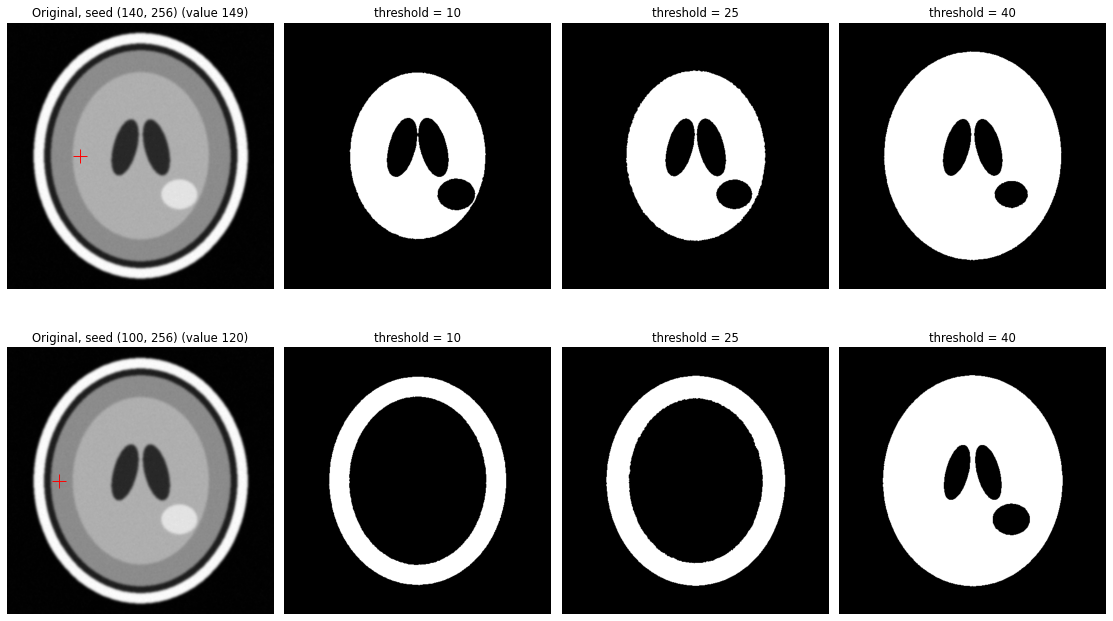

In [11]:
# ---------- TEMPLATE: region growing ----------
def region_grow(image, seed, thresh):
    h, w = image.shape
    mask = np.zeros((h, w), np.uint8)
    seed_val = int(image[seed[1], seed[0]])            # reference intensity
    stack = [seed]
    mask[seed[1], seed[0]] = 255
    while stack:
        x, y = stack.pop()
        for dx in (-1, 0, 1):                          # 8-connected neighbours
            for dy in (-1, 0, 1):
                nx = x + dx
                ny = y + dy
                if 0 <= nx < w and 0 <= ny < h and mask[ny, nx] == 0:
                    if abs(int(image[ny, nx]) - seed_val) <= thresh:
                        mask[ny, nx] = 255
                        stack.append((nx, ny))
    return mask

gray = cv2.imread('images/brain_mri.jpg', cv2.IMREAD_GRAYSCALE)       # EDIT: MRI image
gray = cv2.GaussianBlur(gray, (5, 5), 0)

seeds = [(140, 256), (100, 256)]                                      # EDIT: two seeds (x, y): white matter, grey matter
thresholds = [10, 25, 40]                                             # EDIT: three thresholds

plt.figure(figsize = (16,10))
for r, seed in enumerate(seeds):
    plt.subplot(2,4,r * 4 + 1)
    plt.imshow(gray, cmap = 'gray')
    plt.plot(seed[0], seed[1], 'r+', markersize = 15)
    plt.title('Original, seed %s (value %d)' % (str(seed), gray[seed[1], seed[0]]))
    plt.axis('off')

    for c, t in enumerate(thresholds):
        mask = region_grow(gray, seed, t)
        print('seed %s, threshold %2d -> %6d pixels' % (str(seed), t, np.count_nonzero(mask)))
        cv2.imwrite('output/task6_seed%d_t%d.png' % (r + 1, t), mask)

        plt.subplot(2,4,r * 4 + 2 + c)
        plt.imshow(mask, cmap = 'gray')
        plt.title('threshold = %d' % t)
        plt.axis('off')

plt.tight_layout()
plt.show()

---
# 9. Task 7 - Marker-based watershed (coins)
**Scenario:** touching coins form one white blob after thresholding, so counting connected regions gives the wrong count. Separate them with watershed.

**Idea:** think of the intensity image as a landscape. Flood it from **markers** (one per object); where floods from different markers meet, a **boundary** is built. Good markers = one per coin.

**The 10 stages from the task handout** (the manual's watershed section lists 6 conceptual steps, see A.4)

| # | Stage | Call | Result |
|---|---|---|---|
| 1 | Pre-processing | `cv2.cvtColor(..., COLOR_BGR2GRAY)` (+ optional blur) | gray image |
| 2 | Thresholding | `cv2.threshold(gray, 0, 255, THRESH_BINARY_INV + THRESH_OTSU)` | coins white |
| 3 | Noise removal | `cv2.morphologyEx(th, cv2.MORPH_OPEN, kernel, iterations = 2)` | specks removed |
| 4 | Sure background | `cv2.dilate(opening, kernel, iterations = 3)` | everything outside is surely background |
| 5 | Distance transform | `cv2.distanceTransform(opening, cv2.DIST_L2, 5)` | each white pixel = distance to nearest black pixel (coin centres are peaks) |
| 6 | Sure foreground | `np.uint8(dist > 0.5 * dist.max())` | one blob per coin core |
| 7 | Unknown region | `cv2.subtract(sure_bg, sure_fg)` | the band the watershed must decide |
| 8 | Marker labelling | `ret, markers = cv2.connectedComponents(sure_fg)`; `markers = markers + 1`; `markers[unknown == 255] = 0` | background = 1, coins = 2, 3, ..., unknown = 0 |
| 9 | Watershed | `markers = cv2.watershed(img, markers)` | boundaries = **-1** |
| 10 | Boundary visualisation | `img[markers == -1] = [0, 0, 255]` | red lines between coins |

**Required output:** `Original -> Threshold -> Sure Background -> Distance Transform -> Sure Foreground -> Unknown Region -> Final Watershed`, then check by eye that touching coins are separated.

**Pitfalls**
- `cv2.watershed` needs the **3-channel colour image** (BGR) as its first argument and an **int32** marker image (`connectedComponents` already returns int32).
- The `+1` matters: without it the background is label 0 and watershed treats it as the unknown region.
- Mark the unknown region as **0**, not 255.
- `watershed` **modifies the image copy** you draw on; draw the red boundary on `img.copy()` if you still need the original.
- Number of coins = `markers.max() - 1` (labels 2 .. max), or count labels `> 1` in `np.unique(markers)`.

threshold components : 10
foreground markers   : 17
separated coins      : 17


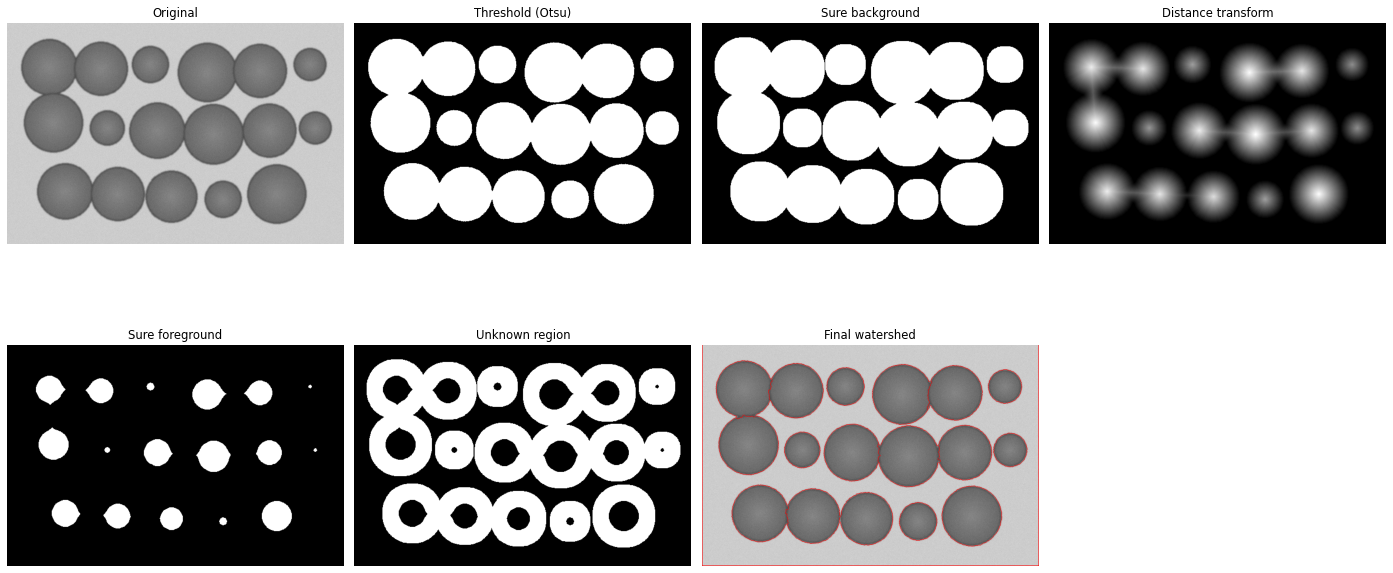

In [12]:
# ---------- TEMPLATE: marker-based watershed ----------
img = cv2.imread('images/coins.jpg')                                  # EDIT: coins image
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)                          # 1. pre-processing

ret, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)   # 2. thresholding

kernel = np.ones((3, 3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations = 2)            # 3. noise removal

sure_bg = cv2.dilate(opening, kernel, iterations = 3)                                  # 4. sure background

dist = cv2.distanceTransform(opening, cv2.DIST_L2, 5)                                  # 5. distance transform

dist_factor = 0.5                                                     # EDIT: fraction of the max distance (Task 8 studies this)
sure_fg = np.uint8(dist > dist_factor * dist.max())                   # 6. sure foreground (0/1)
sure_fg = sure_fg * 255

unknown = cv2.subtract(sure_bg, sure_fg)                                               # 7. unknown region

ret, markers = cv2.connectedComponents(sure_fg)                                        # 8. marker labelling
markers = markers + 1                                                 # background becomes 1 (not 0)
markers[unknown == 255] = 0                                           # unknown = 0

result = img.copy()
markers = cv2.watershed(result, markers)                                               # 9. watershed
result[markers == -1] = [0, 0, 255]                                                    # 10. red boundaries

print('threshold components :', cv2.connectedComponents(thresh)[0] - 1)
print('foreground markers   :', cv2.connectedComponents(sure_fg)[0] - 1)
print('separated coins      :', len([l for l in np.unique(markers) if l > 1]))
cv2.imwrite('output/task7_watershed.png', result)

plt.figure(figsize = (20,10))
plt.subplot(2,4,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Original')
plt.axis('off')

plt.subplot(2,4,2)
plt.imshow(thresh, cmap = 'gray')
plt.title('Threshold (Otsu)')
plt.axis('off')

plt.subplot(2,4,3)
plt.imshow(sure_bg, cmap = 'gray')
plt.title('Sure background')
plt.axis('off')

plt.subplot(2,4,4)
plt.imshow(dist, cmap = 'gray')
plt.title('Distance transform')
plt.axis('off')

plt.subplot(2,4,5)
plt.imshow(sure_fg, cmap = 'gray')
plt.title('Sure foreground')
plt.axis('off')

plt.subplot(2,4,6)
plt.imshow(unknown, cmap = 'gray')
plt.title('Unknown region')
plt.axis('off')

plt.subplot(2,4,7)
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title('Final watershed')
plt.axis('off')

plt.tight_layout()
plt.show()

---
# 10. Task 8 - Tuning the distance-transform threshold
**Scenario:** the Task 7 pipeline merges some coins and splits others. The cause is **how much of each coin counts as sure foreground**, i.e. the threshold applied to the distance transform.

Run Task 7 **four times**, changing only `dist_factor` (the fraction of `dist.max()`), and record for each:

| Experiment | Distance threshold | Foreground markers | Separated regions | Observed result |
|---|---|---|---|---|
| 1 | `0.2 * max` | markers found | regions after watershed | merged / good / lost coins ... |
| 2 | `0.4 * max` | | | |
| 3 | `0.5 * max` | | | |
| 4 | `0.7 * max` | | | |

**How to read the effect**

| Threshold | What happens |
|---|---|
| **too low** (0.1-0.4) | the "sure foreground" of two touching coins still touches, so they get **one marker** and stay **merged** (under-segmentation) |
| **about right** (about 0.5) | each coin core is its own blob: **one marker per coin**, correct separation. The window is narrow: 0.4 still leaves one pair merged, 0.6 already loses the small coins |
| **too high** (0.6+) | only the centres of the **largest** coins survive; **small coins get no marker** and vanish (and a large non-circular object can split into several markers) |

**Best range:** where `foreground markers == separated regions == true coin count`. For the sample image (17 coins) that is about **0.5 x max** (11 -> 16 -> 17 -> 12 regions for 0.2 / 0.4 / 0.5 / 0.7). Real images usually have a wider plateau; widen the sweep (0.1 steps) to find it.

**Pitfalls**
- Change **only** the distance threshold between experiments; keep the Otsu threshold, kernel and iterations fixed.
- The ground-truth count is needed to label a run as merged or split: count the coins by eye first.
- Do **not** replace watershed with another method; the task is about the marker stage.

Exp  Distance threshold Foreground   Regions    Observed result
1    0.2 x max = 11.4   11           11         merged / coins lost
2    0.4 x max = 22.8   16           16         merged / coins lost
3    0.5 x max = 28.5   17           17         correct separation
4    0.7 x max = 39.8   12           12         merged / coins lost


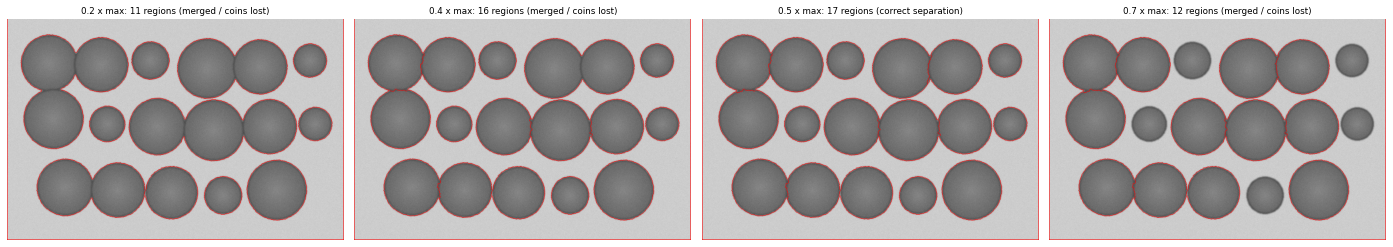

In [13]:
# ---------- TEMPLATE: distance-transform threshold study (table) ----------
img = cv2.imread('images/coins.jpg')                                  # same image / pipeline as Task 7
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
ret, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
kernel = np.ones((3, 3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations = 2)
sure_bg = cv2.dilate(opening, kernel, iterations = 3)
dist = cv2.distanceTransform(opening, cv2.DIST_L2, 5)

true_count = 17                                                       # EDIT: coins you count by eye
factors = [0.2, 0.4, 0.5, 0.7]                                        # EDIT: four distance-transform thresholds

print('%-4s %-18s %-12s %-10s %s' % ('Exp', 'Distance threshold', 'Foreground', 'Regions', 'Observed result'))
plt.figure(figsize = (20,5))
for i, f in enumerate(factors):
    sure_fg = np.uint8(dist > f * dist.max()) * 255
    unknown = cv2.subtract(sure_bg, sure_fg)
    n_markers = cv2.connectedComponents(sure_fg)[0] - 1

    ret, markers = cv2.connectedComponents(sure_fg)
    markers = markers + 1
    markers[unknown == 255] = 0
    result = img.copy()
    markers = cv2.watershed(result, markers)
    result[markers == -1] = [0, 0, 255]
    n_regions = len([l for l in np.unique(markers) if l > 1])

    if n_regions < true_count:
        observed = 'merged / coins lost'
    elif n_regions > true_count:
        observed = 'over-split'
    else:
        observed = 'correct separation'
    print('%-4d %-18s %-12d %-10d %s' % (i + 1, '%.1f x max = %.1f' % (f, f * dist.max()), n_markers, n_regions, observed))

    plt.subplot(1,4,i + 1)
    plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    plt.title('%.1f x max: %d regions (%s)' % (f, n_regions, observed), fontsize = 9)
    plt.axis('off')

plt.tight_layout()
plt.show()

---
# 11. Task 9 - K-Means segmentation
**Scenario:** simplify a colour photograph into a few meaningful colour regions by clustering pixels on colour similarity.

**The workflow** (manual section 2.3.5, code in A.5)

| Step | What | Code |
|---|---|---|
| 1 | Load colour image | `img = cv2.imread(path)` |
| 2 | Pixels as feature vectors: one row per pixel, 3 columns (B, G, R) | `pixels = img.reshape((-1, 3))` |
| 3 | Convert to the numeric type K-Means needs | `pixels = np.float32(pixels)` |
| 4 | Cluster | `ret, labels, centers = cv2.kmeans(pixels, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)` |
| 5 | Reconstruct: replace every pixel by its cluster centre | `centers = np.uint8(centers)`, `seg = centers[labels.flatten()].reshape(img.shape)` |

`criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)`: stop after 100 iterations or when the centres move less than 0.2 (the manual's values). The `10` after `criteria` in `kmeans` is the number of **attempts** (restarts with different random centres; the best is kept).

**Required:** `K = 2, 4, 6` and `Original -> K=2 -> K=4 -> K=6`. Record per K: number of clusters, visual difference from the original, amount of colour simplification, and what each cluster represents.

| K | Typical observation |
|---|---|
| 2 | image collapses to two colours: roughly **subject vs background** (very strong simplification) |
| 4 | main colour regions (petals, centre, leaves, background) separate; flat "poster" look |
| 6 | shading and secondary regions appear; closest to the original, least simplification |

Colour simplification: the result contains **exactly K distinct colours** (check with `len(np.unique(centers, axis=0))`), versus tens of thousands in the original.

**Pitfalls**
- `cv2.kmeans` needs **float32** data of shape `(N, features)`; forgetting `np.float32` raises `cv2.error`.
- Reshape back with the **original** `img.shape`, not `pixels.shape`.
- `labels` has shape `(N, 1)`: use `labels.flatten()` for indexing.
- Large images are slow: `cv2.resize(img, None, fx = 0.5, fy = 0.5)` first.
- K-Means ignores pixel **position**, so two separate regions of the same colour share one cluster.
- Results change slightly between runs (random centres); fix with more `attempts`.

K = 2 | clusters: 2 | colours in result: 2 | cluster shares (%): [44.8 55.2]
       centres (BGR): [[171, 169, 148], [21, 81, 101]]


K = 4 | clusters: 4 | colours in result: 4 | cluster shares (%): [18.7 18.  33.8 29.5]
       centres (BGR): [[9, 114, 174], [110, 121, 112], [185, 179, 155], [13, 56, 57]]


K = 6 | clusters: 6 | colours in result: 6 | cluster shares (%): [15.  11.8 23.7 26.5  7.1 15.9]
       centres (BGR): [[8, 90, 136], [82, 101, 96], [10, 50, 48], [193, 185, 159], [12, 150, 220], [144, 147, 131]]


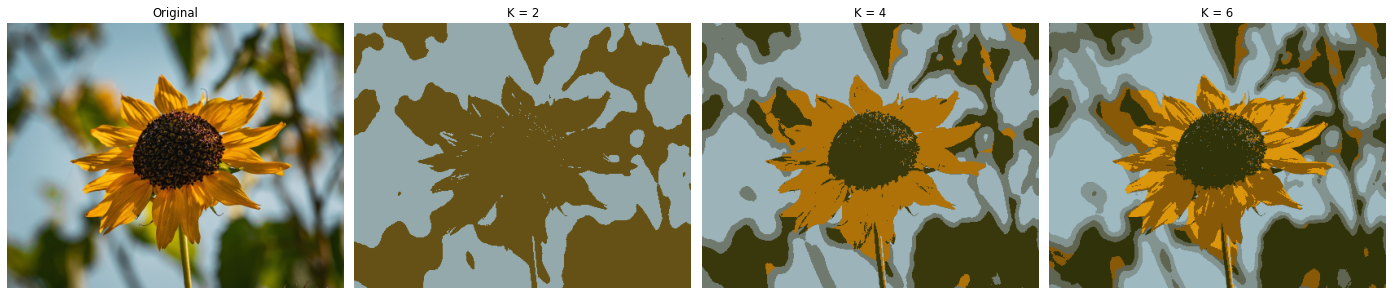

In [14]:
# ---------- TEMPLATE: K-Means colour segmentation ----------
img = cv2.imread('images/scene.jpg')                                  # EDIT: colour image
img = cv2.resize(img, None, fx = 0.5, fy = 0.5, interpolation = cv2.INTER_AREA)       # keep it fast

pixels = img.reshape((-1, 3))                                         # 2. one row per pixel
pixels = np.float32(pixels)                                           # 3. float32 for kmeans

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)

plt.figure(figsize = (20,5))
plt.subplot(1,4,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Original')
plt.axis('off')

for i, K in enumerate([2, 4, 6]):                                     # EDIT: K values
    ret, labels, centers = cv2.kmeans(pixels, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)   # 4. cluster
    centers = np.uint8(centers)
    segmented = centers[labels.flatten()].reshape(img.shape)                                       # 5. reconstruct

    share = np.bincount(labels.flatten()) / len(labels) * 100         # % of pixels in each cluster
    print('K = %d | clusters: %d | colours in result: %d | cluster shares (%%): %s'
          % (K, len(centers), len(np.unique(segmented.reshape(-1, 3), axis = 0)), np.round(share, 1)))
    print('       centres (BGR):', centers.tolist())
    cv2.imwrite('output/task9_kmeans_K%d.png' % K, segmented)

    plt.subplot(1,4,2 + i)
    plt.imshow(cv2.cvtColor(segmented, cv2.COLOR_BGR2RGB))
    plt.title('K = %d' % K)
    plt.axis('off')

plt.tight_layout()
plt.show()

---
# 12. Task 10 - Choose 3 methods for an unknown image
**Scenario:** you get a challenging image and are not told which method to use. Pick **three** methods from the list, justify them, and compare **by what you observe**.

**Method-selection guide (decide from the image, not from habit)**

| If the image has ... | Try | Because |
|---|---|---|
| uneven illumination (document, shadows) | **adaptive threshold** | threshold follows the local brightness |
| a bimodal histogram with even light | **Otsu** | automatic global threshold |
| even light and a known cut | **global threshold** | simplest baseline |
| an object with a distinct colour | **HSV `inRange`** | colour is more stable than brightness |
| boundaries matter, not regions | **Canny** | gradient / hysteresis |
| one connected homogeneous region + a seed | **region growing** | connectivity + intensity similarity |
| touching convex objects | **watershed** | markers + distance transform separate them |
| many colours, want a simplified map | **K-Means** | clusters in colour space |

**For every selected method write down (4 points the handout requires):**

| # | Point | Example for adaptive on the document |
|---|---|---|
| 1 | Assumption the method makes | each neighbourhood is locally uniform: paper is lighter than ink *within the block* |
| 2 | Region it identifies correctly | text on both the bright and the dark side |
| 3 | Part it segments incorrectly | paper noise / shadow edge, thin strokes if `C` is large |
| 4 | Parameter with the greatest effect | `blockSize` (and `C`) |

**Final deliverable:** `Original | Method 1 | Method 2 | Method 3` and a short technical conclusion: *which approach gave the most meaningful regions for this image, and which property of the image made it suitable?* **Base it on what you observed** (give a number or a visible failure), not on which algorithm you already know.

**Example conclusion (document image):** adaptive Gaussian thresholding produced the most meaningful regions: its text mask has similar ink coverage on both halves of the page (about 11 % left, 6 % right), whereas global `T = 127` turns 81 % of the dark half black and Otsu (`T = 139`) 94 %. The property that made it suitable is the **illumination gradient across the page**: only a local threshold can follow it.

**Pitfalls**
- Three methods must be **different** (two global thresholds with different `T` are one method).
- Show measured evidence (pixel percentage, region count) in the conclusion.

Global T = 127             left:  10.6 %   right:  81.1 %
Otsu T = 139               left:  12.0 %   right:  93.9 %
Adaptive Gaussian 31 / 10  left:  11.1 %   right:   6.2 %


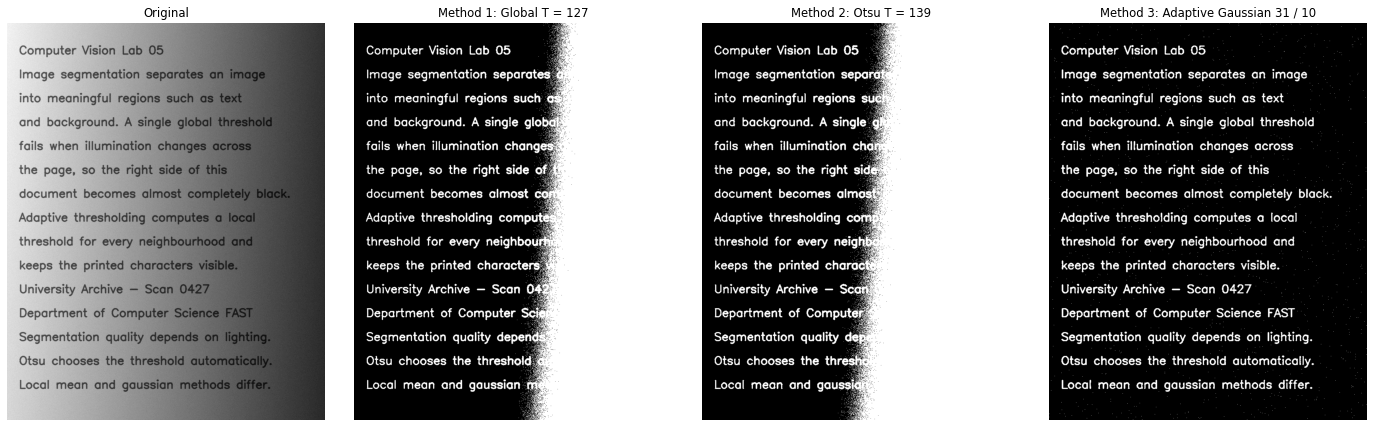


Conclusion: write which method gave the most meaningful regions and which property of the image made it suitable.


In [15]:
# ---------- TEMPLATE: three methods on one image + numeric evidence ----------
gray = cv2.imread('images/document.jpg', cv2.IMREAD_GRAYSCALE)        # EDIT: the challenging image

ret, method1 = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV)                          # Method 1: global
otsu_T, method2 = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)       # Method 2: Otsu
method3 = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                cv2.THRESH_BINARY_INV, 31, 10)                               # Method 3: adaptive

# evidence: foreground % in each half of the page (a good text mask is similar on both)
w = gray.shape[1] // 2
names = ['Global T = 127', 'Otsu T = %d' % otsu_T, 'Adaptive Gaussian 31 / 10']
for name, m in zip(names, (method1, method2, method3)):
    print('%-26s left: %5.1f %%   right: %5.1f %%' % (name, m[:, :w].mean() / 2.55, m[:, w:].mean() / 2.55))

cv2.imwrite('output/task10_method3_adaptive.png', method3)

plt.figure(figsize = (20,6))
plt.subplot(1,4,1)
plt.imshow(gray, cmap = 'gray')
plt.title('Original')
plt.axis('off')

for i, (name, m) in enumerate(zip(names, (method1, method2, method3))):
    plt.subplot(1,4,2 + i)
    plt.imshow(m, cmap = 'gray')
    plt.title('Method %d: %s' % (i + 1, name))
    plt.axis('off')

plt.tight_layout()
plt.show()

print('\nConclusion: write which method gave the most meaningful regions and which property of the image made it suitable.')

---
# 13. Function quick reference

| Function | Signature / notes |
|---|---|
| `cv2.imread(path, cv2.IMREAD_GRAYSCALE)` | load as one channel; returns `None` if the path is wrong |
| `cv2.cvtColor(img, cv2.COLOR_BGR2GRAY / COLOR_BGR2HSV / COLOR_BGR2RGB)` | colour-space conversion |
| `cv2.GaussianBlur(img, (5,5), 0)` | smooth before thresholding / Canny |
| `ret, mask = cv2.threshold(g, T, 255, type)` | global; `ret` is `T` (the Otsu value when `THRESH_OTSU`) |
| `mask = cv2.adaptiveThreshold(g, 255, method, type, blockSize, C)` | `method`: `ADAPTIVE_THRESH_MEAN_C` / `GAUSSIAN_C`; `blockSize` odd |
| `cv2.inRange(hsv, lower, upper)` | 255 where **all channels** are inside the bounds |
| `cv2.bitwise_and(img, img, mask = mask)` | keep original pixels where the mask is 255 |
| `cv2.Canny(g, low, high)` | edge map 0/255; hysteresis with two thresholds |
| `cv2.morphologyEx(m, cv2.MORPH_OPEN, kernel, iterations = 2)` | erosion then dilation: removes small specks |
| `cv2.dilate(m, kernel, iterations = 3)` | grows white regions (sure background) |
| `cv2.distanceTransform(m, cv2.DIST_L2, 5)` | distance of each white pixel to the nearest black pixel (float32) |
| `cv2.subtract(a, b)` | saturating subtraction of two uint8 images (unknown region) |
| `cv2.connectedComponents(m)` | returns `(count including background, int32 label image)` |
| `cv2.watershed(img_bgr, markers)` | `markers` int32; result has `-1` on boundaries |
| `cv2.kmeans(data32, K, None, criteria, attempts, flags)` | returns `(compactness, labels, centers)` |
| `np.count_nonzero(mask)` | number of foreground pixels |
| `np.unique(markers)` | the set of labels |
| `plt.hist(g.ravel(), 256, [0, 256])` | histogram of a gray image |
| `cv2.imwrite(path, img)` | save the result (BGR or gray `uint8`) |

**Matching mask logic**

| Need | Call |
|---|---|
| Combine two masks (union) | `cv2.bitwise_or(m1, m2)` |
| Overlap of two masks | `cv2.bitwise_and(m1, m2)` |
| Invert a mask | `cv2.bitwise_not(m)` |

---
# 14. Common errors & exam checklist

| Symptom | Cause | Fix |
|---|---|---|
| `cv2.error` in `adaptiveThreshold` | `blockSize` even or 1, or image not single-channel | odd `blockSize` >= 3, load / convert to gray |
| Text is white on black when you expected the opposite | wrong threshold type | `THRESH_BINARY_INV` for dark objects on light background |
| `ValueError: too many values to unpack` on `cv2.threshold` | forgot it returns **two** values | `ret, mask = cv2.threshold(...)` |
| Otsu gives a poor / odd threshold | passed a non-zero `T`, or histogram is not bimodal | pass `0`; blur first; use adaptive for uneven light |
| `inRange` mask is empty | looking for hue in the wrong colour space (RGB vs BGR) or `H` > 179 | `COLOR_BGR2HSV`; OpenCV hue is 0-179 |
| Red object only half detected | red wraps around hue 0 | two ranges `0-10` and `170-179`, then `cv2.bitwise_or` |
| Canny shows noise everywhere | no blur, `low` too small | `GaussianBlur` first, raise `low` |
| Canny shows almost nothing | `high` too large | lower `high` (about 2-3x `low`) |
| Region grows to the whole image | threshold too large, or seed on a boundary | smaller threshold, seed in the middle of a region |
| Region growing gives wrong differences | `uint8` subtraction wraps | `int(a) - int(b)` |
| `cv2.watershed` error / assertion | markers not `int32`, or image not 3-channel BGR | use `connectedComponents` output; pass the colour image |
| Watershed floods everything (no coins separated) | background label left as 0 | `markers = markers + 1` and `markers[unknown == 255] = 0` |
| Coins merged / lost | distance threshold too low / too high | sweep 0.2-0.7 x max and compare counts |
| `cv2.kmeans` error | data not `float32` or wrong shape | `np.float32(img.reshape((-1, 3)))` |
| K-Means result has the wrong size | reshaped with `pixels.shape` | `.reshape(img.shape)` |
| Colours wrong in `plt.imshow` | BGR instead of RGB | `cv2.cvtColor(img, cv2.COLOR_BGR2RGB)` |
| Gray image shown in colour | no colormap | `plt.imshow(m, cmap = 'gray')` |
| `FileNotFoundError` on `imwrite` | folder does not exist | `os.makedirs('output', exist_ok = True)` |

### Exam checklist
1. Look at the image and its histogram first; **decide the method from the image**.
2. Load in the right mode: gray for thresholding / Canny / region growing, colour for HSV / watershed / K-Means.
3. Blur lightly (`GaussianBlur`) before thresholding, Canny or region growing.
4. Make the object **white** in every mask (`THRESH_BINARY_INV` for dark objects).
5. Show **Original + every result** side by side with titles that contain the parameter values.
6. **Print** the parameters / counts and write one line of justification for each.
7. Answer the **"why / what happens"** question the task asks (use the model answers above, phrased with your own numbers).
8. Save the final output with `cv2.imwrite`.